# \[R Shiny\] EHR data

SEOYEON CHOI  
2025-11-06

> An electronic health record (EHR) data example includes both
> structured data like demographics, diagnoses, and lab results, and
> unstructured data such as free-text clinical notes and images.

[data
kaggle](https://www.kaggle.com/datasets/anuchhetry/electronic-health-record?resource=download)

[link](https://seoyeonchoi.shinyapps.io/ehr_data/)

**About Dataset**

-   Electronic Health record Dataset

-   Hello everyone, kindly find below sample dataset containing Patient
    Id, Patient Demographic (Male, Female, Unknown)

-   Feel free to analyze the data using various tools.

-   This dataset contains below columns:

    -   patientunitstayid, patienthealthsystemstayid: Unique Patient Id
    -   Patient Demographics:
    -   gender: Male, Female, Unknown
    -   age
    -   ethnicity
    -   Hospital Details:
    -   hospitalid: Each hospital was given unique id
    -   wardid: Ward Id is given in which patient was treated
    -   apacheadmissiondx: Disease diagnosed
    -   admissionheight: Height of the patients
    -   hospitaladmittime24: Admission time to the hospital
    -   hospitaladmitsource: Department Source of the admission
    -   hospitaldischargeyear: Discharge year from the hospital
    -   hospitaldischargetime24: Discharge time from the hospital
    -   hospitaldischargelocation: Patient Discharge to which location
        (Home, Death, Other hospital. etc)
    -   hospitaldischargestatus (Alive, Expired)

-   Hospital Unit Details:

    -   unittype: Unit in which admitted
    -   unitadmittime24: Time of admision to the Unit
    -   unitadmitsource: Department source for the unit
    -   unitvisitnumber: No. of times visited
    -   unitstaytype: Admit, readmit, etc
    -   admissionweight: Weight during the admission
    -   dischargeweight: Weight during the Discharge
    -   unitdischargetime24: Discharge time from the Unit
    -   unitdischargelocation: Patient Discharge to which location
        (Home, Death, Other hospital. etc)
    -   unitdischargestatus: (Alive, Expired)

-   Date of admission and discharge is not given in the dataset, you can
    assume it to be 24 hours data.

-   I have worked on a dashboard assessing no. of patients admitted,
    avg. duration of hospital stay, disease condition for which they are
    admitted etc.

-   You can also do your analysis. Do share your findings with me.
    Thanks!

------------------------------------------------------------------------

1 Patient Identifiers (환자 식별자)

| 변수명                      | 설명                                                                                |
|-------------------------|-----------------------------------------------|
| `patientunitstayid`         | 각 환자의 병동(혹은 ICU 단위) 내 체류에 대한 고유 ID                                |
| `patienthealthsystemstayid` | 병원 시스템 내 환자의 전체 입원 단위별 고유 ID (한 환자가 여러 unit을 옮길 수 있음) |

2 Patient Demographics (환자 인적정보)

| 변수명      | 설명                                                  |
|-------------|-------------------------------------------------------|
| `gender`    | 성별 — Male, Female, Unknown                          |
| `age`       | 환자 나이                                             |
| `ethnicity` | 인종/민족 (예: Caucasian, Asian, African American 등) |

3 Hospital Details (병원 전체 입원 정보)

| 변수명                      | 설명                                                          |
|--------------------------|----------------------------------------------|
| `hospitalid`                | 병원 고유 ID                                                  |
| `wardid`                    | 병원 내 병동 ID                                               |
| `apacheadmissiondx`         | 입원 시 진단명 (예: Sepsis, Stroke 등)                        |
| `admissionheight`           | 환자 키 (cm 또는 m 단위)                                      |
| `hospitaladmittime24`       | 병원 입원 시각 (24시간 형식)                                  |
| `hospitaladmitsource`       | 입원 출처 (예: 응급실, 외래, 타 병원 등)                      |
| `hospitaldischargeyear`     | 퇴원 연도                                                     |
| `hospitaldischargetime24`   | 병원 퇴원 시각 (24시간 형식)                                  |
| `hospitaldischargelocation` | 환자가 퇴원 후 이동한 곳 (예: Home, Other hospital, Death 등) |
| `hospitaldischargestatus`   | 퇴원 상태 (Alive, Expired 등 생존 여부)                       |

4 Hospital Unit Details (병원 내 세부 병동/Unit 정보)

| 변수명                  | 설명                                             |
|----------------------------|--------------------------------------------|
| `unittype`              | 입원한 병동/유닛 유형 (예: ICU, General Ward 등) |
| `unitadmittime24`       | 병동 입실 시각 (24시간 형식)                     |
| `unitadmitsource`       | 병동 입실 출처 (예: 응급실, 수술실 등)           |
| `unitvisitnumber`       | 병동 방문 횟수 (입·재입원 구분 가능)             |
| `unitstaytype`          | 입원 유형 (Admit, Readmit 등)                    |
| `admissionweight`       | 입원 시 체중                                     |
| `dischargeweight`       | 퇴원 시 체중                                     |
| `unitdischargetime24`   | 병동 퇴실 시각                                   |
| `unitdischargelocation` | 병동 퇴실 후 이동 장소                           |
| `unitdischargestatus`   | 병동 퇴실 상태 (Alive, Expired)                  |

In [26]:
import pandas as pd
import re

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('../../../delete/EHR.csv')

In [20]:
df['operator'] = df['age'].str.replace(r'[0-9.]','',regex=True)

In [21]:
df['age_numeric'] = df['age'].str.extract(r'([0-9.]+)').astype(float)

In [31]:
gender_missing = (~df['gender'].isin(['Male','Female'])).sum()

In [33]:
age_missing = df['age'].isna().sum()

In [77]:
df_gender = df[df['gender'].isin(['Male','Female'])]

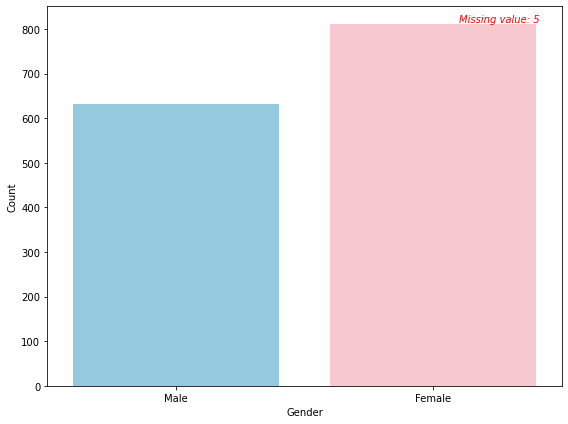

In [85]:
plt.figure(figsize=(8,6))
sns.countplot(data = df_gender, x='gender', palette=['skyblue', 'pink'])
plt.title('')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.text(x=1.1, y=df_gender['gender'].value_counts().max(),
        s=f"Missing value: {gender_missing}", ha='left',va='bottom',fontsize=10, color='red',style='italic')
plt.tight_layout()

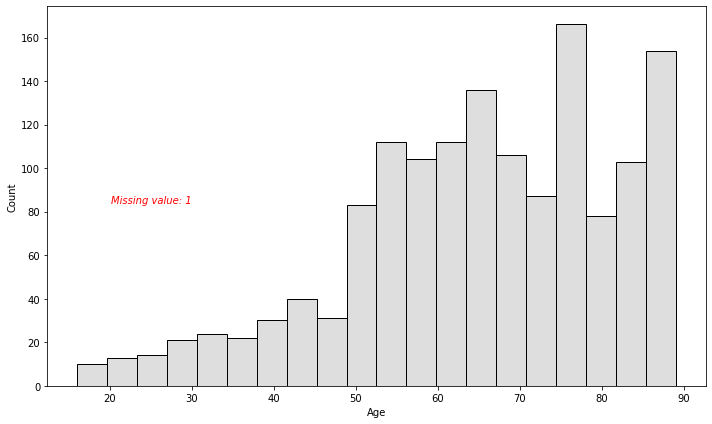

In [94]:
plt.figure(figsize=(10,6))
sns.histplot(df['age_numeric'],bins=20, kde=False,color='lightgrey')
plt.title('')
plt.xlabel('Age')
plt.ylabel('Count')
plt.text(x=30, y=df['age_numeric'].value_counts().max(),
        s=f"Missing value: {age_missing}", ha='right',va='bottom',fontsize=10, color='red',style='italic')
plt.tight_layout()

-   `ndarray.size` : Number of elements in the array.

In [100]:
df_ethnicity = df[df['ethnicity'].notna() & (df['ethnicity'] != "")].groupby('ethnicity').size().reset_index(name='n')

In [101]:
df_ethnicity['prop'] = df_ethnicity['n'] / df_ethnicity['n'].sum()

In [104]:
df_ethnicity = df_ethnicity.sort_values('n')

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = df_ethnicity, y = 'ethnicity',x='n',hue = 'ethnicity',dodge = False,palette='tab20b')
plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('Ethnicity')
plt.title('Ethnicity Distribution (logscale)')
plt.legend([],[],frameon=False)
plt.tight_layout()